In [45]:
import torch
import torch.nn.functional as F
import pandas as pd
import wandb
import matplotlib.pyplot as plt
%matplotlib inline

In [67]:
wandb.login()

True

In [47]:
words = open("names.txt").read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [48]:
#lookup table from characters to ints
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi["."] = 0
itos = {i:s for s,i in stoi.items()}
print (itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [49]:
block_size = 3 # context length; how many characters do we take to predict the next one
X, Y = [], []
for w in words:
    # print (w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print (''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [50]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [51]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [52]:
# 2d embeddings
C = torch.randn((27, 2))

In [53]:
# equivalent ways of indexing
C[5]
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([ 0.1657, -0.1849])

In [54]:
#second input is number of neurons
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [66]:
# # concatenate the 3 2d embeddings for each character to make tensor shapes work
# emb = C[X]
# emb.view(32, 6) == torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1)
# h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # or emb.view(emb.shape[0], 6)

In [27]:
h.shape # hidden layer of activations for every one of our 32 examples

torch.Size([32, 100])

In [28]:
# output set of neurons
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [29]:
logits = h @ W2 + b2
counts = logits.exp()
prob = counts / counts.sum(1, keepdims = True)
prob.shape

torch.Size([32, 27])

In [30]:
loss = -prob[torch.arange(32), Y].log().mean()
prob[torch.arange(32), Y]

tensor([5.5617e-09, 4.1474e-12, 6.4503e-09, 6.9015e-17, 3.7259e-10, 1.5712e-09,
        1.2202e-05, 4.9549e-01, 2.0667e-07, 2.8725e-02, 7.4491e-08, 2.7332e-08,
        1.0567e-13, 2.9181e-12, 9.8239e-12, 1.5517e-07, 9.8526e-01, 3.6430e-08,
        7.5214e-14, 1.0515e-05, 1.4592e-03, 1.8796e-05, 9.5371e-07, 6.2403e-12,
        4.7821e-11, 2.7960e-10, 2.0167e-10, 3.1077e-08, 2.4398e-03, 1.5296e-01,
        3.5037e-10, 1.6950e-06])

In [119]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [140]:
# hyperparameters
hyperparameters = {
    "emb_dim": 20,
    "neurons": 250,
    "batch_size": 256,
    "learning_rate": 0.05,
    "epochs": 50000
}

In [141]:
run = wandb.init(
    project = "makemore-mlp-reproduction",
    config = hyperparameters
)

In [187]:
wandb.finish()

dev_loss,█▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁
epoch,▄▂▂▇▁▁▁▂▃▄█▇▂▆█▆▇▁▃▄▆▃▆▆▇▂▄▅▁▂▁▂▂▂▃▇█▂▃▃
log loss,▇▆█▄▄▂▄▃▃▂▂▃▂▄▄▁▂▃▃▂▃▂▄▅▃▃▃▃▂▃▂▂▁▃▂▂▄▂▂▃
loss,▇▆▅▄█▄▅▄▅▅▅▃▃▄▆▅▄▃▅▅▅▄▅▆▃▂▄▆▄▅▃▅▂▃▂▄▂▂▁▄
dev_loss,2.13724
epoch,49999
log loss,0.75761
loss,2.13317


In [142]:
# "more respectable"
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, run.config.emb_dim), generator=g)
W1 = torch.randn(((run.config.emb_dim*block_size), run.config.neurons), generator=g)
b1 = torch.randn(run.config.neurons, generator=g)
W2 = torch.randn((run.config.neurons, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [143]:
sum(p.nelement() for p in parameters) # number of parameters in total

22567

In [144]:
for p in parameters:
    p.requires_grad = True

In [145]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [146]:
# lri = []
# lossi = []
# stepi = []

# lr = 0.1

# for i in range(30000):
    
#     # minibatch
#     ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    
#     # forward pass
#     emb = C[Xtr[ix]] 
#     h = torch.tanh(emb.view(-1, input_size) @ W1 + b1) # (32, 200)
#     logits = h @ W2 + b2 # (32, 27)
#     # counts = logits.exp()
#     # prob = counts / counts.sum(1, keepdims = True)
#     # loss = -prob[torch.arange(32), Y].log().mean()
#     loss = F.cross_entropy(logits, Ytr[ix])
#     # print (loss.item())
 
#     # backward pass
#     for p in parameters:
#         p.grad = None
#     loss.backward()
    
#     # update
#     # lr = lrs[i]
#     for p in parameters:
#         p.data += -lr * p.grad

#     #track stats
#     # lri.append(lre[i])
#     stepi.append(epoch)
#     lossi.append(loss.item())

# print (loss.item())

In [184]:
for epoch in range(run.config.epochs):
    
    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (run.config.batch_size,))
    
    # forward pass
    emb = C[Xtr[ix]] 
    h = torch.tanh(emb.view(-1, (run.config.emb_dim*block_size)) @ W1 + b1)
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Ytr[ix])
 
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = run.config.learning_rate
    for p in parameters:
        p.data += -lr * p.grad

    #logging stats
    wandb.log({"loss": loss.item(), "epoch": epoch, "log loss": torch.log(loss)})

print (torch.log(loss))

tensor(0.7576, grad_fn=<LogBackward0>)


In [185]:
emb = C[Xdev] 
h = torch.tanh(emb.view(-1, (run.config.emb_dim*block_size)) @ W1 + b1)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
wandb.log({"dev_loss": loss.item()})
loss

tensor(2.1372, grad_fn=<NllLossBackward0>)

In [186]:
emb = C[Xte] 
h = torch.tanh(emb.view(-1, (run.config.emb_dim*block_size)) @ W1 + b1)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Yte)
loss

tensor(2.1375, grad_fn=<NllLossBackward0>)

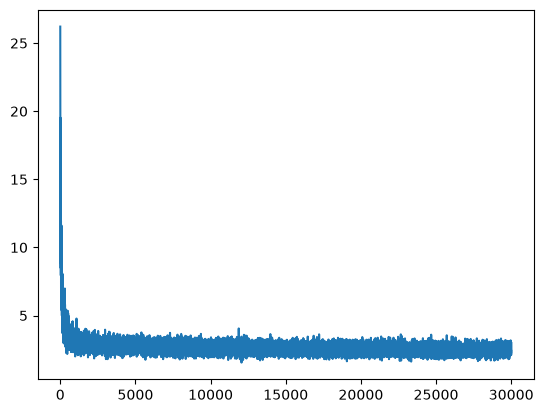

In [178]:
plt.plot(stepi, lossi)

In [ ]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))